Exercise on Principal Component Analysis

a. Load the "Wine Dataset", available in the scikit learn library (use "load_wine()").

b. Implement two functions that transform the data according to the PCA. One implementation is based on the eigendecomposition, while the other is based on the singular value decomposition.

c. Apply the two implementations of the PCA transformation to the wine data and verify they yield the same result (compare the variance of the principal components, and the principal component scores). For a further check, compare your own PCA implementations with the builtin one from sklearn. Are the results still the same?

d. Perform the dimensionality reduction by motivating the choice for the new dimensionality value. Repeat this step two times: in the first case do not standardize the original data, in the second standardize it. To further understand the effect of standardization, set the number of components for the PCA to two, and plot the transformed data.

e. Verify that applying the PCA decorrelates the features. To do so, compare the correlation matrix of the original data and of the transformed data.


In [25]:
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd

# Carico il dataset
wine_data = load_wine()

# Creo il DataFrame
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Aggiungo anche la colonna dei target (il tipo di vino)
df['target'] = wine_data.target
df.head()
# Carica il Wine Dataset

# Estrai i dati e le etichette
X = wine_data.data # Matrice delle features (178 campioni x 13 features)
y = wine_data.target  # Vettore delle etichette di classe (0, 1, o 2)
feature_names = wine_data.feature_names  # Nomi delle 13 features
target_names = wine_data.target_names  # Nomi delle 3 classi di vino
# Se df è il tuo DataFrame del Wine Dataset
stats = df.describe().T[['mean', 'std', 'min', 'max']]
print(stats)


                                    mean         std     min      max
alcohol                        13.000618    0.811827   11.03    14.83
malic_acid                      2.336348    1.117146    0.74     5.80
ash                             2.366517    0.274344    1.36     3.23
alcalinity_of_ash              19.494944    3.339564   10.60    30.00
magnesium                      99.741573   14.282484   70.00   162.00
total_phenols                   2.295112    0.625851    0.98     3.88
flavanoids                      2.029270    0.998859    0.34     5.08
nonflavanoid_phenols            0.361854    0.124453    0.13     0.66
proanthocyanins                 1.590899    0.572359    0.41     3.58
color_intensity                 5.058090    2.318286    1.28    13.00
hue                             0.957449    0.228572    0.48     1.71
od280/od315_of_diluted_wines    2.611685    0.709990    1.27     4.00
proline                       746.893258  314.907474  278.00  1680.00
target              

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2) #creo un oggetto PCA con 2 componenti principali
X_pca = pca.fit_transform(X) #applico la PCA alle prime 10 colonne del dataset, escludendo la 10-esima colonna (dove si trovano i label)

# Il rapporto di varianza (PVE)
print("Varianza Spiegata Relativa (PVE):")
print(pca.explained_variance_ratio_)


varianze_assolute = pca.explained_variance_ 
varianza_totale=np.sum(varianze_assolute)
varianza_spiegata_ratio = varianze_assolute / varianza_totale #il totale di tutte varianza_spiegata_ratio sarà 1
print(np.sum(varianza_spiegata_ratio))
tot=0
for i, v in enumerate(varianza_spiegata_ratio[:10]):
    print(f"Varianza spiegata dalla PC{i+1}: {v:.4f}")
    tot=tot+v
print(tot) 


Varianza Spiegata Relativa (PVE):
[0.99809123 0.00173592]
1.0
Varianza spiegata dalla PC1: 0.9983
Varianza spiegata dalla PC2: 0.0017
1.0


**eigendecomposition**

In [27]:

X_mean= np.mean(X, axis=0) #calcolo la media delle prime 10 colonne del dataset
#axis=0: calcolo la media per ogni colonna, axis=1: calcolo la media per ogni riga
X_std_dev = np.std(X, axis=0)
X_centered= (X - X_mean)



C = (1 / (X_centered.shape[0] - 1)) * X_centered.T @ X_centered #10X10
eigvals, eigvecs = np.linalg.eig(C)

idx = np.argsort(eigvals)[::-1] # Ottengo gli indici per l'ordinamento decrescente
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx] # Ordino gli autovettori in base agli autovalori


W = eigvecs[:, :] #prendo solo le prime 2 colonne degli autovettori
X_pca_manual = X_centered @ W #proietto i dati centrati sulle prime 2 componenti principali tramite prodotto matriciale tra X senza media e W
# Gli autovalori sono già le varianze di PC1, PC2, ..., PCn



In [28]:

varianze_assolute = eigvals 
varianza_totale=np.sum(eigvals)
varianza_spiegata_ratio = eigvals / varianza_totale #il totale di tutte varianza_spiegata_ratio sarà 1
print(np.sum(varianza_spiegata_ratio))
tot=0
for i, v in enumerate(varianza_spiegata_ratio[:10]):
    print(f"Varianza spiegata dalla PC{i+1}: {v:.4f}")
    tot=tot+v
print(tot) 



0.9999999999999999
Varianza spiegata dalla PC1: 0.9981
Varianza spiegata dalla PC2: 0.0017
Varianza spiegata dalla PC3: 0.0001
Varianza spiegata dalla PC4: 0.0001
Varianza spiegata dalla PC5: 0.0000
Varianza spiegata dalla PC6: 0.0000
Varianza spiegata dalla PC7: 0.0000
Varianza spiegata dalla PC8: 0.0000
Varianza spiegata dalla PC9: 0.0000
Varianza spiegata dalla PC10: 0.0000
0.9999993273866999


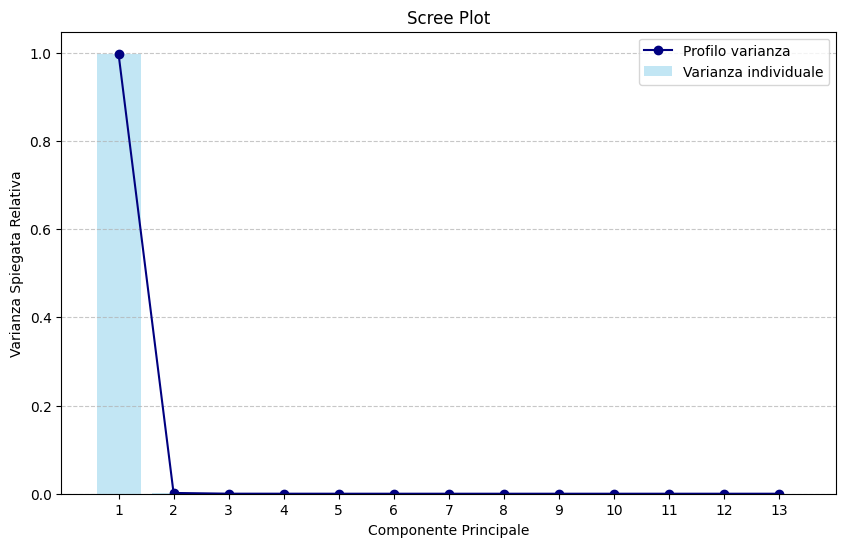

In [29]:

import matplotlib.pyplot as plt
import numpy as np

# Supponiamo che varianza_spiegata_ratio sia il tuo array di 10 valori
x_range = range(1, len(varianza_spiegata_ratio) + 1)

plt.figure(figsize=(10, 6))

# 1. Grafico a barre (Varianza individuale)
plt.bar(x=x_range, height=varianza_spiegata_ratio, alpha=0.5, align='center', 
        label='Varianza individuale', color='skyblue')

# 2. Grafico a linee (Il "profilo" dello scree plot)
plt.plot(x_range, varianza_spiegata_ratio, marker='o', color='navy', linestyle='-', 
         label='Profilo varianza')

# Personalizzazione
plt.ylabel('Varianza Spiegata Relativa')
plt.xlabel('Componente Principale')
plt.title('Scree Plot')
plt.xticks(x_range) # Forza la visualizzazione di tutti i numeri da 1 a 10
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



**singular value decomposition**

In [30]:
import numpy as np

U, Sigma, VT = np.linalg.svd(X_centered)

#Sigma è un vettore colonna 10X1
# Per ottenere la matrice Sigma completa, bisogna creare una matrice diagonale a partire dal vettore dei singolari Sigma:

# 1. Crei la matrice di zeri
Sigma_matrix = np.zeros_like(X_centered, dtype=float)

# 2. Riempi la diagonale con i valori singolari ottenuti dalla SVD
np.fill_diagonal(Sigma_matrix, Sigma)

# 3. Ora calcoli il rango
rango = np.linalg.matrix_rank(Sigma_matrix)
print(f"Il rango della matrice Sigma è: {rango}")

# 1. Calcoliamo i lambda (varianze) dai valori singolari
lambdas = Sigma**2 
# Calcoliamo la somma totale per il denominatore della formula PVE
varianza_totale = np.sum(lambdas)
print(varianza_totale)

m = 0
somma_parziale = 0

for l in lambdas:
    somma_parziale += l
    m += 1 # Incrementiamo il numero di componenti usate
    #Senza la divisione, avresti solo un numero assoluto (es. 450.000).
    #  Dividendo per il totale, ottieni un valore tra 0 e 1 (es. 0.95), 
    # che rappresenta la percentuale di informazione conservata:
    # Calcoliamo il PVE attuale: (somma parziale / somma totale)
    pve_attuale = somma_parziale / varianza_totale
    
    if pve_attuale >= 0.95:
        print(f"Numero di componenti (m) per il 95%: {m}")
        print(f"PVE raggiunto: {pve_attuale:.4f}")
        break # Fermiamo il ciclo appena raggiungiamo la soglia

Il rango della matrice Sigma è: 13
17592296.383508466
Numero di componenti (m) per il 95%: 1
PVE raggiunto: 0.9981


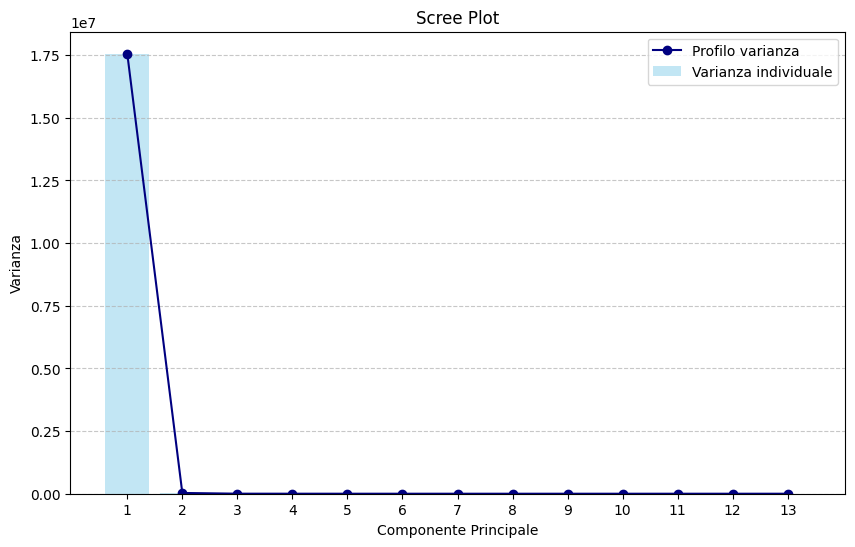

In [31]:

import matplotlib.pyplot as plt
import numpy as np

# Supponiamo che varianza_spiegata_ratio sia il tuo array di 10 valori
x_range = range(1, len(lambdas) + 1)

plt.figure(figsize=(10, 6))

# 1. Grafico a barre (Varianza individuale)
plt.bar(x=x_range, height=lambdas, alpha=0.5, align='center', 
        label='Varianza individuale', color='skyblue')

# 2. Grafico a linee (Il "profilo" dello scree plot)
plt.plot(x_range, lambdas, marker='o', color='navy', linestyle='-', 
         label='Profilo varianza')

# Personalizzazione
plt.ylabel('Varianza')
plt.xlabel('Componente Principale')
plt.title('Scree Plot')
plt.xticks(x_range) # Forza la visualizzazione di tutti i numeri da 1 a 10
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



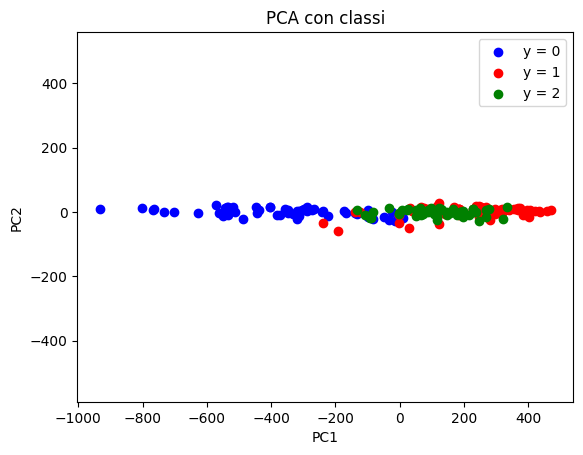

In [32]:

plt.figure()

plt.scatter(
    X_pca_manual[y == 0, 0],
    X_pca_manual[y == 0, 1],
    c="blue",
    label="y = 0",
)
plt.scatter(
    X_pca_manual[y == 1, 0],
    X_pca_manual[y == 1, 1],
    c="red",
    label="y = 1",
)
plt.scatter(
    X_pca_manual[y == 2, 0],
    X_pca_manual[y == 2, 1],
    c="green",
    label="y = 2",
)
plt.axis("equal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA con classi")
plt.show()

In [33]:
import numpy as np

# --- MIGLIORAMENTO 1: Standardizzazione (Cruciale!) ---
# Senza questo, la PC1 dominerà sempre tutto a causa delle unità di misura.
X_std = (X_centered / np.std(X, axis=0))

# --- MIGLIORAMENTO 2: SVD sui dati scalati ---
U, Sigma, VT = np.linalg.svd(X_std, full_matrices=False)

# --- MIGLIORAMENTO 3: Rango con Tolleranza ---
rango_reale = np.linalg.matrix_rank(X_std) 


print(f"Rango matematico (tutte le dimensioni): {rango_reale}")

# --- MIGLIORAMENTO 4: Calcolo PVE elegante ---
lambdas = Sigma**2
pve = lambdas / np.sum(lambdas)
pve_cumulato = np.cumsum(pve)

# Trova m in modo più "Pythonic"
m = np.argmax(pve_cumulato >= 0.95) + 1

print(f"\nSomma PVE: {np.sum(pve)}")
print(f"Numero di componenti per il 95%: {m}")
print(f"PVE raggiunto con {m} componenti: {pve_cumulato[m-1]:.4f}")

# Visualizzazione pulita
for i, v in enumerate(pve):
    print(f"PC{i+1}: {v:.4f} (Cumulato: {pve_cumulato[i]:.4f})")

Rango matematico (tutte le dimensioni): 13

Somma PVE: 0.9999999999999998
Numero di componenti per il 95%: 10
PVE raggiunto con 10 componenti: 0.9617
PC1: 0.3620 (Cumulato: 0.3620)
PC2: 0.1921 (Cumulato: 0.5541)
PC3: 0.1112 (Cumulato: 0.6653)
PC4: 0.0707 (Cumulato: 0.7360)
PC5: 0.0656 (Cumulato: 0.8016)
PC6: 0.0494 (Cumulato: 0.8510)
PC7: 0.0424 (Cumulato: 0.8934)
PC8: 0.0268 (Cumulato: 0.9202)
PC9: 0.0222 (Cumulato: 0.9424)
PC10: 0.0193 (Cumulato: 0.9617)
PC11: 0.0174 (Cumulato: 0.9791)
PC12: 0.0130 (Cumulato: 0.9920)
PC13: 0.0080 (Cumulato: 1.0000)


c. Apply the two implementations of the PCA transformation to the wine data and verify they yield the same result (compare the variance of the principal components, and the principal component scores). For a further check, compare your own PCA implementations with the builtin one from sklearn. Are the results still the same?

Relazione tra Valori Singolari e Autovalori$$\sigma_i^2 = \lambda_i$$Proprietà dei Vettori SingolariI vettori singolari destri in $V$ sono le direzioni principali (ovvero gli autovettori della matrice di covarianza $X^\top X$).Calcolo delle Componenti Principali ($T$)Le componenti principali (score) possono essere ottenute in due modi equivalenti:Utilizzando i vettori singolari destri:$$T = XV$$Utilizzando i vettori singolari sinistri e i valori singolari:$$T = U\Sigma V^\top V \implies T = U\Sigma$$

In [34]:
# Calcolo SVD per confronto
U, Sigma, VT = np.linalg.svd(X_centered, full_matrices=False)
lambdas_svd = (Sigma**2) / (X.shape[0] - 1)

# Sklearn
pca_sk = PCA().fit(X_centered)

print("Varianze PC1 (EVD):", eigvals[0])
print("Varianze PC1 (SVD):", lambdas_svd[0])
print("Varianze PC1 (Sklearn):", pca_sk.explained_variance_[0])

# Nel contesto della SVD (Singular Value Decomposition) 
# e della PCA, il comando np.diag(Sigma) trasforma il vettore dei valori singolari 
# in una matrice diagonale per permettere il calcolo delle componenti principali.
X_pca_svd = U @ np.diag(Sigma)# (oppure X_scaled @ VT.T)

#Sklearn: 
X_pca_sk = pca_sk.transform(X_centered)
# Verifica se la differenza assoluta è vicina allo zero
diff_evd_svd = np.abs(X_pca_manual) - np.abs(X_pca_svd)
print(f"Differenza massima EVD-SVD: {np.max(np.abs(diff_evd_svd)):.2e}")

diff_sk = np.abs(X_pca_manual) - np.abs(X_pca_sk)
print(f"Differenza massima EVD-Sklearn: {np.max(np.abs(diff_sk)):.2e}")

Varianze PC1 (EVD): 99201.78951748091
Varianze PC1 (SVD): 99201.78951748094
Varianze PC1 (Sklearn): 99201.78951748092
Differenza massima EVD-SVD: 9.09e-13
Differenza massima EVD-Sklearn: 1.36e-10


d. Perform the dimensionality reduction by motivating the choice for the new dimensionality value. Repeat this step two times: in the first case do not standardize the original data, in the second standardize it. To further understand the effect of standardization, set the number of components for the PCA to two, and plot the transformed data.



In [35]:
X_centered_std= (X - X_mean)/ X_std_dev #centro i dati rispetto alla media

C = (1 / (X_centered_std.shape[0] - 1)) * X_centered_std.T @ X_centered_std 

eigvals, eigvecs = np.linalg.eig(C)

idx = np.argsort(eigvals)[::-1] # Ottengo gli indici per l'ordinamento decrescente
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx] # Ordino gli autovettori in base agli autovalori


W = eigvecs[:, :] #prendo solo le prime 2 colonne degli autovettori
X_pca_manual_std = X_centered_std @ W #proietto i dati centrati sulle prime 2 componenti principali tramite prodotto matriciale tra X senza media e W
# Gli autovalori sono già le varianze di PC1, PC2, ..., PCn

varianze_assolute = eigvals 
varianza_totale=np.sum(eigvals)
varianza_spiegata_ratio = eigvals / varianza_totale #il totale di tutte varianza_spiegata_ratio sarà 1
print(np.sum(varianza_spiegata_ratio))
tot=0
for i, v in enumerate(varianza_spiegata_ratio[:10]):
    print(f"Varianza spiegata dalla PC{i+1}: {v:.4f}")
    tot=tot+v
print(tot) 



1.0000000000000002
Varianza spiegata dalla PC1: 0.3620
Varianza spiegata dalla PC2: 0.1921
Varianza spiegata dalla PC3: 0.1112
Varianza spiegata dalla PC4: 0.0707
Varianza spiegata dalla PC5: 0.0656
Varianza spiegata dalla PC6: 0.0494
Varianza spiegata dalla PC7: 0.0424
Varianza spiegata dalla PC8: 0.0268
Varianza spiegata dalla PC9: 0.0222
Varianza spiegata dalla PC10: 0.0193
0.9616971684450646


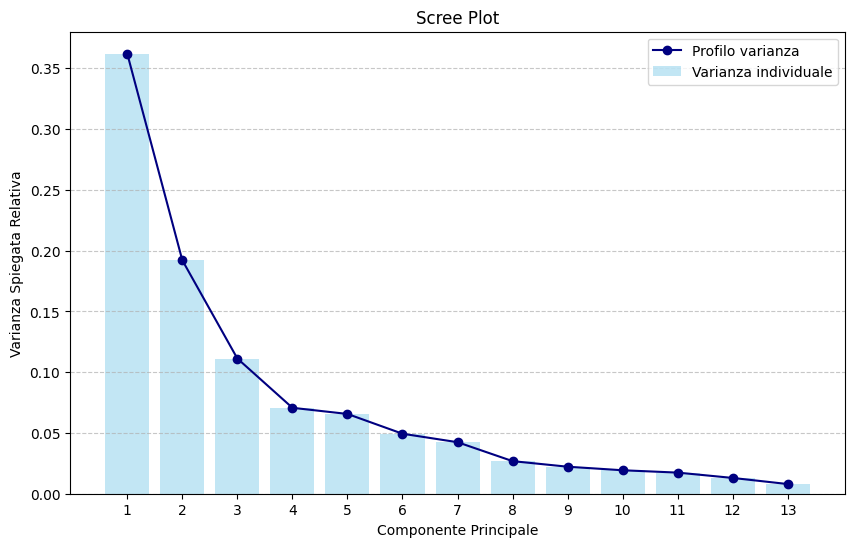

In [36]:

import matplotlib.pyplot as plt
import numpy as np

# Supponiamo che varianza_spiegata_ratio sia il tuo array di 10 valori
x_range = range(1, len(varianza_spiegata_ratio) + 1)

plt.figure(figsize=(10, 6))

# 1. Grafico a barre (Varianza individuale)
plt.bar(x=x_range, height=varianza_spiegata_ratio, alpha=0.5, align='center', 
        label='Varianza individuale', color='skyblue')

# 2. Grafico a linee (Il "profilo" dello scree plot)
plt.plot(x_range, varianza_spiegata_ratio, marker='o', color='navy', linestyle='-', 
         label='Profilo varianza')

# Personalizzazione
plt.ylabel('Varianza Spiegata Relativa')
plt.xlabel('Componente Principale')
plt.title('Scree Plot')
plt.xticks(x_range) # Forza la visualizzazione di tutti i numeri da 1 a 10
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [37]:
import numpy as np

X_std = (X_centered_std / np.std(X, axis=0))

U, Sigma, VT = np.linalg.svd(X_centered_std, full_matrices=False)

rango_reale = np.linalg.matrix_rank(X_centered_std) 


print(f"Rango matematico (tutte le dimensioni): {rango_reale}")

# --- MIGLIORAMENTO 4: Calcolo PVE elegante ---
lambdas = Sigma**2
pve = lambdas / np.sum(lambdas)
pve_cumulato = np.cumsum(pve)

# Trova m in modo più "Pythonic"
m = np.argmax(pve_cumulato >= 0.95) + 1

print(f"\nSomma PVE: {np.sum(pve)}")
print(f"Numero di componenti per il 95%: {m}")
print(f"PVE raggiunto con {m} componenti: {pve_cumulato[m-1]:.4f}")

# Visualizzazione pulita
for i, v in enumerate(pve):
    print(f"PC{i+1}: {v:.4f} (Cumulato: {pve_cumulato[i]:.4f})")

Rango matematico (tutte le dimensioni): 13

Somma PVE: 0.9999999999999998
Numero di componenti per il 95%: 10
PVE raggiunto con 10 componenti: 0.9617
PC1: 0.3620 (Cumulato: 0.3620)
PC2: 0.1921 (Cumulato: 0.5541)
PC3: 0.1112 (Cumulato: 0.6653)
PC4: 0.0707 (Cumulato: 0.7360)
PC5: 0.0656 (Cumulato: 0.8016)
PC6: 0.0494 (Cumulato: 0.8510)
PC7: 0.0424 (Cumulato: 0.8934)
PC8: 0.0268 (Cumulato: 0.9202)
PC9: 0.0222 (Cumulato: 0.9424)
PC10: 0.0193 (Cumulato: 0.9617)
PC11: 0.0174 (Cumulato: 0.9791)
PC12: 0.0130 (Cumulato: 0.9920)
PC13: 0.0080 (Cumulato: 1.0000)


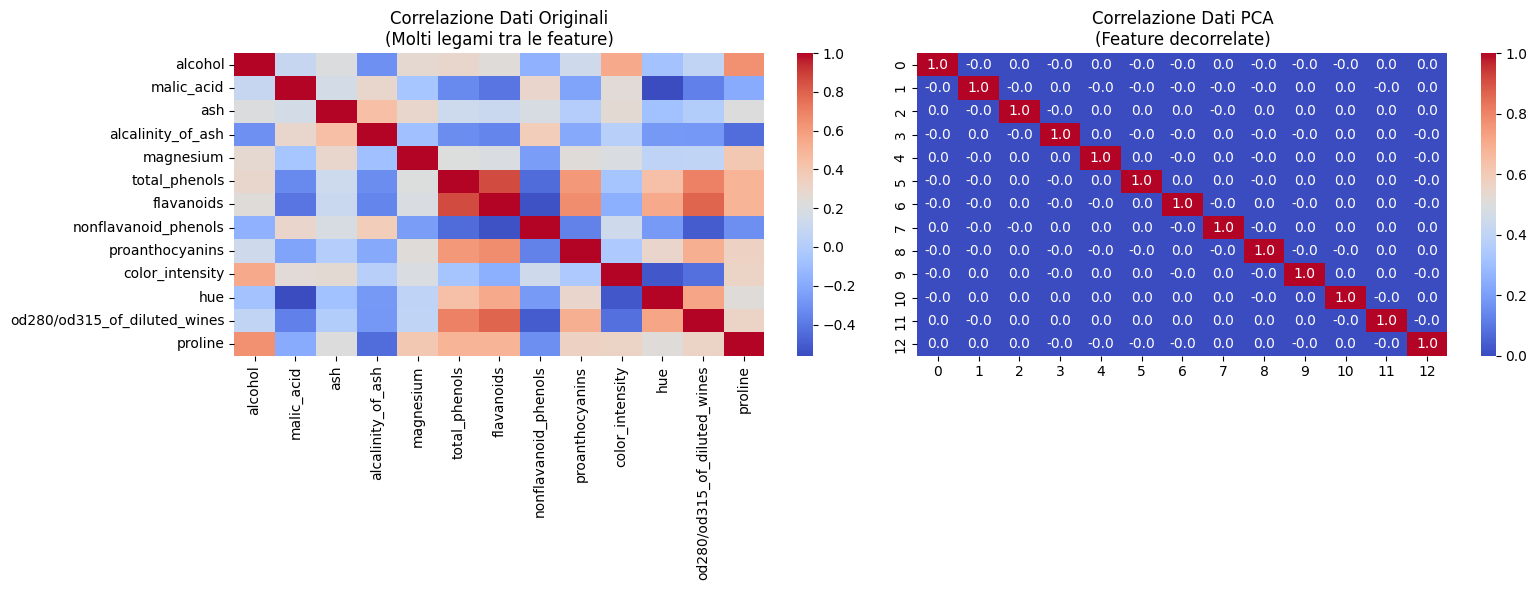

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Matrice di correlazione dei dati originali (scalati)
df_orig = pd.DataFrame(X_centered_std, columns=wine_data.feature_names)
corr_orig = df_orig.corr()

# 2. Matrice di correlazione dei dati trasformati (PC scores)
# Usiamo i risultati della tua PCA (es. le prime 13 componenti)
df_pca = pd.DataFrame(X_pca_manual_std)
corr_pca = df_pca.corr()

# 3. Visualizzazione con Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_orig, annot=False, cmap='coolwarm', ax=ax1)
ax1.set_title("Correlazione Dati Originali\n(Molti legami tra le feature)")

sns.heatmap(corr_pca, annot=True, fmt=".1f", cmap='coolwarm', ax=ax2)
ax2.set_title("Correlazione Dati PCA\n(Feature decorrelate)")

plt.tight_layout()
plt.show()

1. Analisi dei Dati Originali (Heatmap a Sinistra)
Struttura della Correlazione: La prima heatmap mostra una matrice densa con numerosi blocchi colorati in rosso (correlazione positiva) e blu (correlazione negativa).

Legami tra le Feature: Variabili come total_phenols, flavanoids e od280/od315_of_diluted_wines mostrano una forte interdipendenza. Questa ridondanza informativa indica che i dati originali contengono informazioni sovrapposte

2. Analisi dei Dati Trasformati - PCA (Heatmap a Destra)
Decorrelazione Completa: La seconda heatmap mostra una struttura puramente diagonale. Tutti i valori fuori dalla diagonale principale sono pari a 0.0 (o valori infinitesimali dovuti alla precisione di calcolo).

Indipendenza Lineare: Questo risultato conferma che le Componenti Principali (PC) estratte sono linearmente indipendenti tra loro. Ogni PC cattura una quota di varianza specifica e non ridondante rispetto alle altre.